In [ ]:
import sys 
sys.path.append("../")
import src.KZ as kz
import matplotlib.pyplot as plt
import generate_data as g
import numpy as np


In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(11, 1024)),
    layers.SimpleRNN(256, activation='softsign'),
    layers.Dense(1024)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       263,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,104 (2.25 MB)

 Trainable params: 591,104 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
d = g.load(128, outdir='../data')

T_SAMPLE = 50
X = g.window(d, T_SAMPLE).astype('float32')     # (N, 11, 1024)
Y = d['phi_final'].astype('float32')            # (N, 1024)

print(X.shape, Y.shape)
print('input  scale:', np.abs(X).std())
print('target scale:', np.abs(Y).std())

(3000, 11, 1024) (3000, 1024)
input  scale: 0.00835485
target scale: 0.16194487


In [15]:
hist = model.fit(X, Y, epochs=60, batch_size=10, validation_split=0.2)

Epoch 1/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3797 - val_loss: 0.3055
Epoch 2/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2605 - val_loss: 0.2513
Epoch 3/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2216 - val_loss: 0.2241
Epoch 4/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1959 - val_loss: 0.2069
Epoch 5/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1779 - val_loss: 0.1843
Epoch 6/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1610 - val_loss: 0.1680
Epoch 7/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1498 - val_loss: 0.1599
Epoch 8/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1363 - val_loss: 0.1466
Epoch 9/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1297 - val_loss: 0.1419
Epoch 10/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1213 - val_loss: 0.1340
Epoch 11/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1114 - val_loss: 0.1173
Epoch 12/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

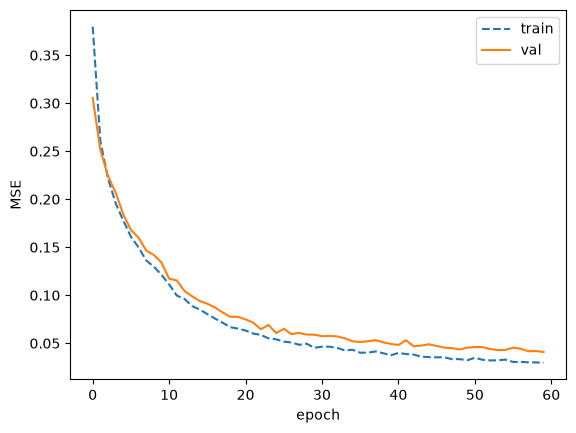

In [16]:
plt.plot(hist.history['loss'], '--', label='train')
plt.plot(hist.history['val_loss'], '-', label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()

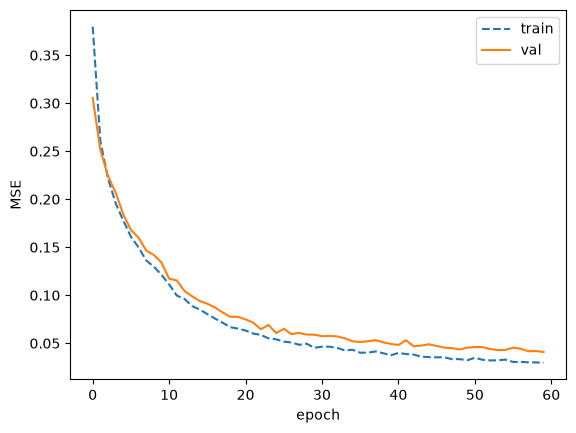

In [18]:
plt.plot(hist.history['loss'], '--', label='train')
plt.plot(hist.history['val_loss'], '-', label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


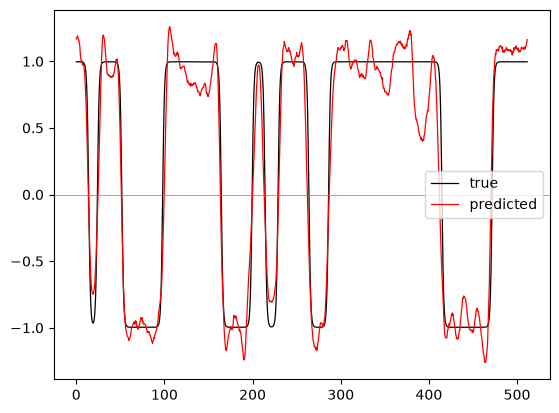

In [19]:
Yp = model.predict(X[-40:])          # validation samples
i = 0
plt.plot(kz.grid(), Y[-40:][i], 'k-', lw=0.9, label='true')
plt.plot(kz.grid(), Yp[i], 'r-', lw=0.9, label='predicted')
plt.axhline(0, color='grey', lw=0.5); plt.legend()

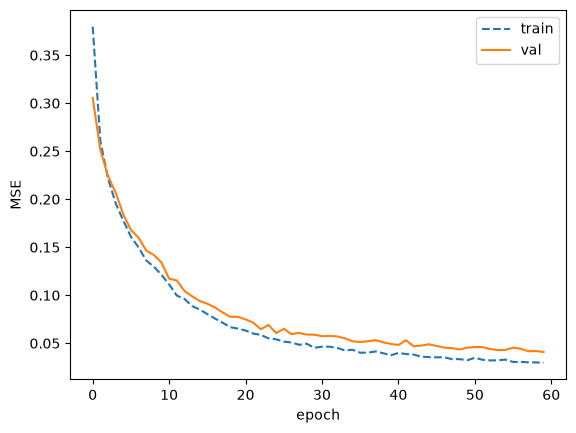

In [20]:
plt.plot(hist.history['loss'], '--', label='train')
plt.plot(hist.history['val_loss'], '-', label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()

([], [])

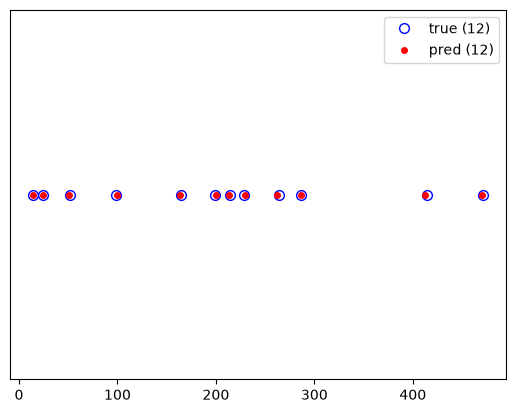

In [21]:
pt = kz.defect_positions(Y[-40:][i].astype(np.float64))
pp = kz.defect_positions(Yp[i].astype(np.float64))
plt.plot(pt, np.zeros(len(pt)), 'o', mfc='none', mec='b', ms=7, label=f'true ({len(pt)})')
plt.plot(pp, np.zeros(len(pp)), 'o', color='r', ms=4, label=f'pred ({len(pp)})')
plt.legend(); plt.yticks([])

In [23]:
for T_SAMPLE in [-80, 20, 50, 70]:
    X = g.window(d, T_SAMPLE).astype('float32')
    Y = d['phi_final'].astype('float32')
    model = keras.Sequential([
        keras.layers.Input(shape=(11, 1024)),
        keras.layers.SimpleRNN(256, activation='softsign'),
        keras.layers.Dense(1024)
    ])
    model.compile(optimizer='adam', loss='mse')
    h = model.fit(X, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    print(T_SAMPLE, h.history['val_loss'][-1])

-80 1.0547558069229126
20 0.28348028659820557
50 0.04032529890537262
70 0.02343696355819702


In [25]:
def lowpass(X, kc):
    F = np.fft.rfft(X, axis=-1)
    k = 2*np.pi*np.fft.rfftfreq(X.shape[-1], d=kz.dx)
    F[..., k > kc] = 0
    return np.fft.irfft(F, n=X.shape[-1], axis=-1)


T_SAMPLE = 50
X = g.window(d, T_SAMPLE).astype('float32')
Y = d['phi_final'].astype('float32')

k_hat = 1.0/(np.sqrt(2)*(kz.TAU/(2*kz.eta))**0.25)     # 1/xi_hat
KCS   = k_hat*np.array([0.25, 0.5, 1, 2, 4, 8, 1e6])

val = []
for kc in KCS:
    Xf = lowpass(X, kc).astype('float32')
    model = keras.Sequential([
        keras.layers.Input(shape=(11, 1024)),
        keras.layers.SimpleRNN(256, activation='softsign'),
        keras.layers.Dense(1024)
    ])
    model.compile(optimizer='adam', loss='mse')
    h = model.fit(Xf, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    val.append(h.history['val_loss'][-1])
    print(f'kc/k_hat={kc/k_hat:8.2f}  val={val[-1]:.4f}')

val = np.array(val)

kc/k_hat=    0.25  val=0.5640
kc/k_hat=    0.50  val=0.1760
kc/k_hat=    1.00  val=0.0408
kc/k_hat=    2.00  val=0.0437
kc/k_hat=    4.00  val=0.0399
kc/k_hat=    8.00  val=0.0399
kc/k_hat=1000000.00  val=0.0457


In [28]:
T_SAMPLE = 50
X = g.window(d, T_SAMPLE).astype('float32')
Y = d['phi_final'].astype('float32')
x = kz.grid()

k_hat = 1.0/(np.sqrt(2)*(kz.TAU/(2*kz.eta))**0.25)
Xf = lowpass(X, k_hat).astype('float32')

def train(Xin):
    m = keras.Sequential([keras.layers.Input(shape=(11, 1024)),
                          keras.layers.SimpleRNN(256, activation='softsign'),
                          keras.layers.Dense(1024)])
    m.compile(optimizer='adam', loss='mse')
    m.fit(Xin, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    return m

m_full = train(X)
m_filt = train(Xf)

n_val = int(0.2*len(X))
P_full = m_full.predict(X[-n_val:],  verbose=0)
P_filt = m_filt.predict(Xf[-n_val:], verbose=0)

j       = 0                      # which validation sample to show
y_true  = Y[-n_val:][j]
in_full = X[-n_val:][j, 5]       # middle snapshot of the window
in_filt = Xf[-n_val:][j, 5]
p_full  = P_full[j]
p_filt  = P_filt[j]

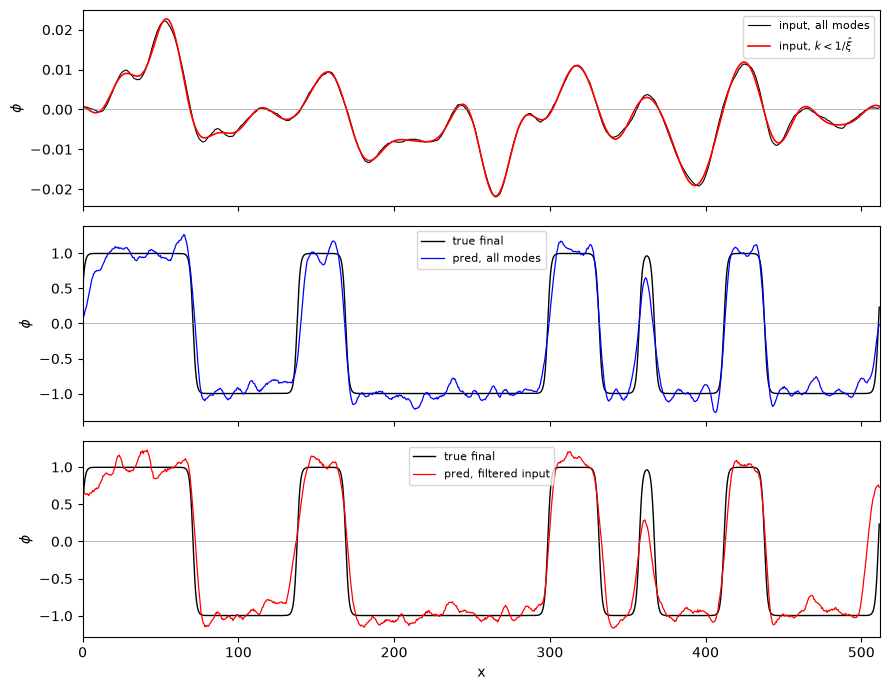

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

ax[0].plot(x, in_full, 'k-', lw=0.8, label='input, all modes')
ax[0].plot(x, in_filt, 'r-', lw=1.2, label=r'input, $k<1/\hat\xi$')
ax[0].legend(fontsize=8); ax[0].set_ylabel(r'$\phi$')

ax[1].plot(x, y_true, 'k-', lw=1.0, label='true final')
ax[1].plot(x, p_full, 'b-', lw=0.9, label='pred, all modes')
ax[1].legend(fontsize=8); ax[1].set_ylabel(r'$\phi$')

ax[2].plot(x, y_true, 'k-', lw=1.0, label='true final')
ax[2].plot(x, p_filt, 'r-', lw=0.9, label='pred, filtered input')
ax[2].legend(fontsize=8); ax[2].set_ylabel(r'$\phi$'); ax[2].set_xlabel('x')

for a in ax:
    a.axhline(0, color='grey', lw=0.4)
    a.set_xlim(0, kz.L())
plt.tight_layout()

In [30]:
print('MSE  full:', ((P_full - Y[-n_val:])**2).mean())
print('MSE  filt:', ((P_filt - Y[-n_val:])**2).mean())

nt = kz.count_defects(Y[-n_val:].astype(np.float64))
nf = kz.count_defects(P_full.astype(np.float64))
ng = kz.count_defects(P_filt.astype(np.float64))
print('count accuracy  full:', (nf == nt).mean())
print('count accuracy  filt:', (ng == nt).mean())

MSE  full: 0.040165506
MSE  filt: 0.03818305
count accuracy  full: 0.78
count accuracy  filt: 0.8066666666666666


In [32]:
print(np.bincount(nf - nt + 6))     # offset to keep indices positive

[  0   0  11   0  84   0 468   0  36   0   1]
